# River discharge data in Nile stations.

- This dataset was downloaded from [kaggle](https://www.kaggle.com/datasets/karltarbet/global-monthly-river-discharge-data-set-rivdis).
- Below, we show how to load and process the already downloaded files.

In [1]:
import pandas as pd

# Globe_RivDIS.dat Monthly average discharge in cubic meters/sec 262791 records
river_discharge = pd.read_csv("inputs/river_discharge/RIVDIS.DAT", sep="|")
# Globe_RivDIS.stn  1020
stations_info = pd.read_csv("inputs/river_discharge/STATION.DAT", sep="|")

In [2]:
stations_info.where(stations_info.RIVER == "Nile").dropna()

,POINTID,STATION,RIVER,LAT,LON,MAPCODE,ELEV,COUNTRY,CONT,OCEAN,BASIN,BASN_STN,AREA,NXT_PNT,RELIABLE,REASON
42,76.0,Dongola,Nile,19.18,30.48,F3,212,Sudan,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1487,1.0,
739,1159.0,El Ekhsase,Nile,29.71,31.26,F2,20,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,,1.0,
740,1160.0,Assiut,Nile,27.18,31.10,F2,51,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1159,1.0,
741,1162.0,Nag Hammadi,Nile,26.21,32.00,F2,69,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1160,1.0,
742,1166.0,Esna,Nile,25.43,32.55,F2,80,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1162,1.0,
743,1167.0,Gaafra,Nile,24.31,32.90,F2,85,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1166,1.0,
956,1487.0,Aswan Dam,Nile,23.96,32.90,,,Egypt,Africa,Mediterranean Sea,Mediterranean Sea,Nile Basin,,1167,1.0,


In [3]:
river_discharge_station = river_discharge.where(
    river_discharge.POINTID == 1167
).dropna()
river_discharge_station.DISCHRG = river_discharge_station.DISCHRG.astype(float)
river_discharge_station.set_index(
    pd.to_datetime(
        [
            f"{int(year)}-{int(month)}"
            for year, month in zip(
                river_discharge_station.YEAR, river_discharge_station.MONTH
            )
        ],
        yearfirst=True,
    ),
    inplace=True,
)
river_discharge_station

,POINTID,YEAR,MONTH,DISCHRG
1973-01-01,1167.0,1973.0,1.0,1336.0
1973-02-01,1167.0,1973.0,2.0,1450.0
1973-03-01,1167.0,1973.0,3.0,1609.0
1973-04-01,1167.0,1973.0,4.0,1523.0
1973-05-01,1167.0,1973.0,5.0,1922.0
...,...,...,...,...
1984-08-01,1167.0,1984.0,8.0,2350.0
1984-09-01,1167.0,1984.0,9.0,1840.0
1984-10-01,1167.0,1984.0,10.0,1725.0
1984-11-01,1167.0,1984.0,11.0,1493.0


<Axes: >

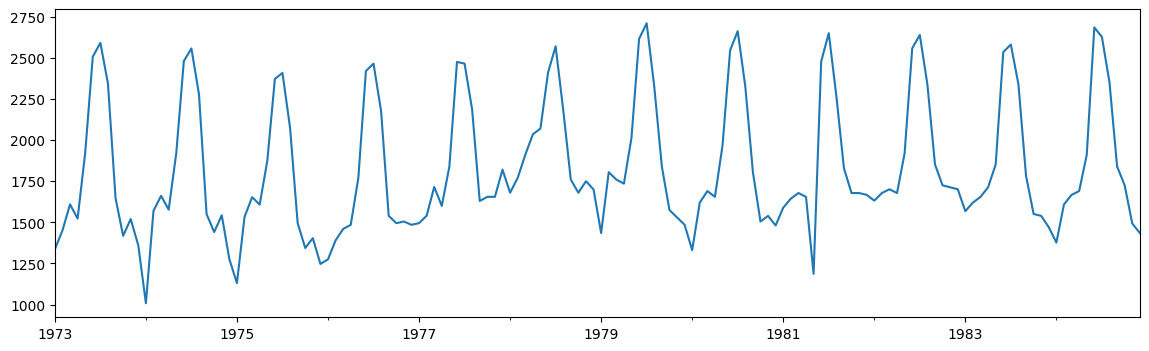

In [4]:
river_discharge_station.DISCHRG.plot(figsize=(14, 4))